# Phrase-Based Statistical Machine Translation (PBSMT): Version 2
## Myanmar (Burmese) Language: Grapheme - Phoneme Translation

## Setup

In [1]:
from pathlib import Path
from IPython.display import Image

In [2]:
ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data" / "cleaned"
TEST_SGM_DIR = DATA_DIR / "test-sgm"
BASELINE_DIR = ROOT / "baseline"

MOSES_DIR = "/home/lawun330/NLP/ubuntu-17.04"
GIZA_DIR = "/home/lawun330/NLP/giza-pp"

## Run 2: A Deeper Look

Both graphs show that there is a problem in calculating NIST-BLEU scores.

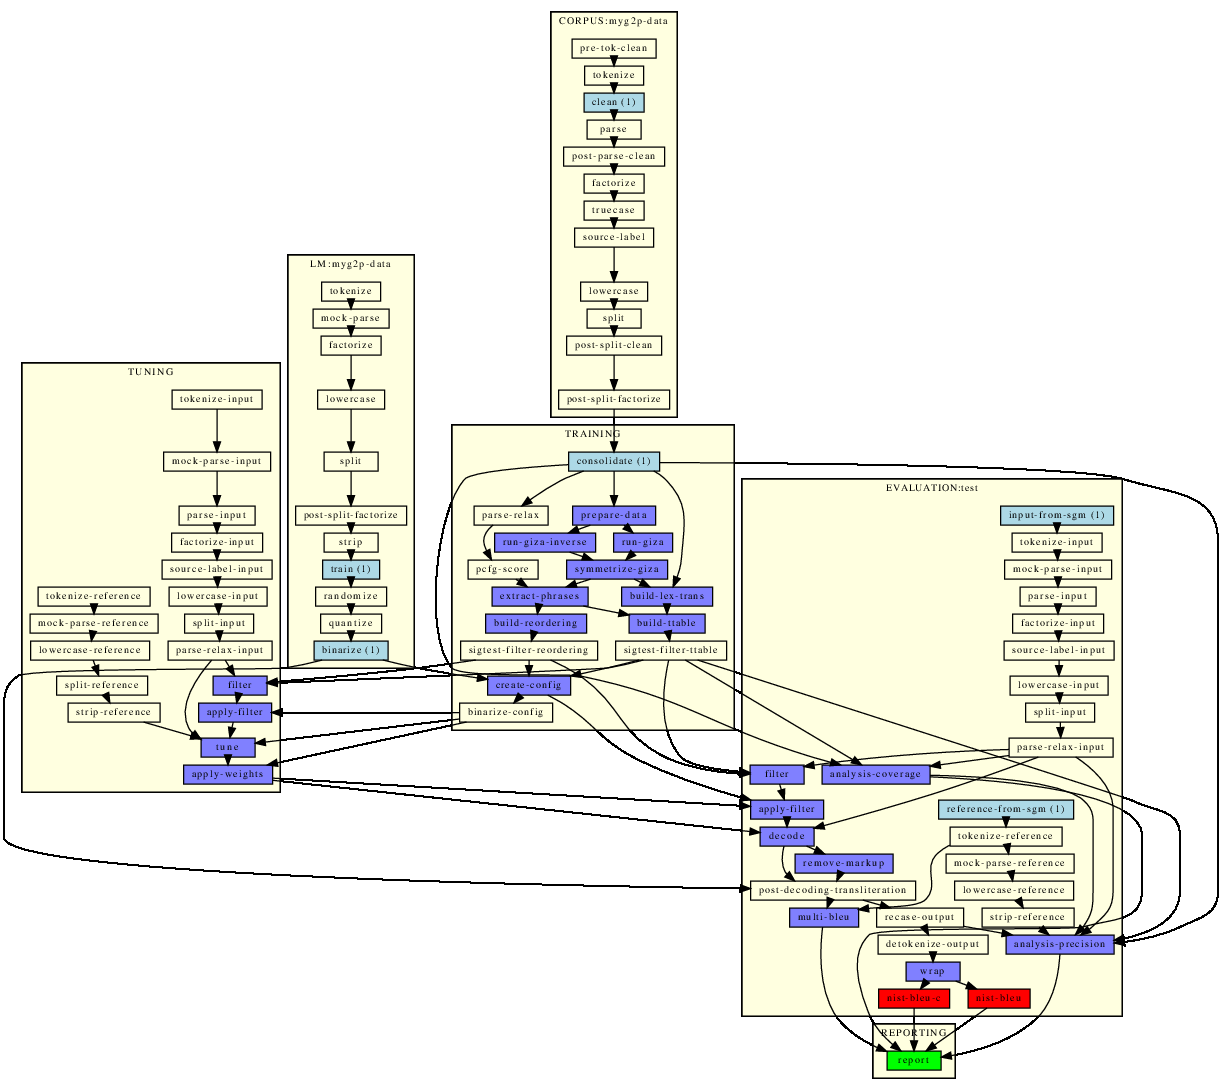

In [3]:
# check graphs
Image(filename=f'{BASELINE_DIR}/my-ph/steps/2/graph.2.png', width=800)

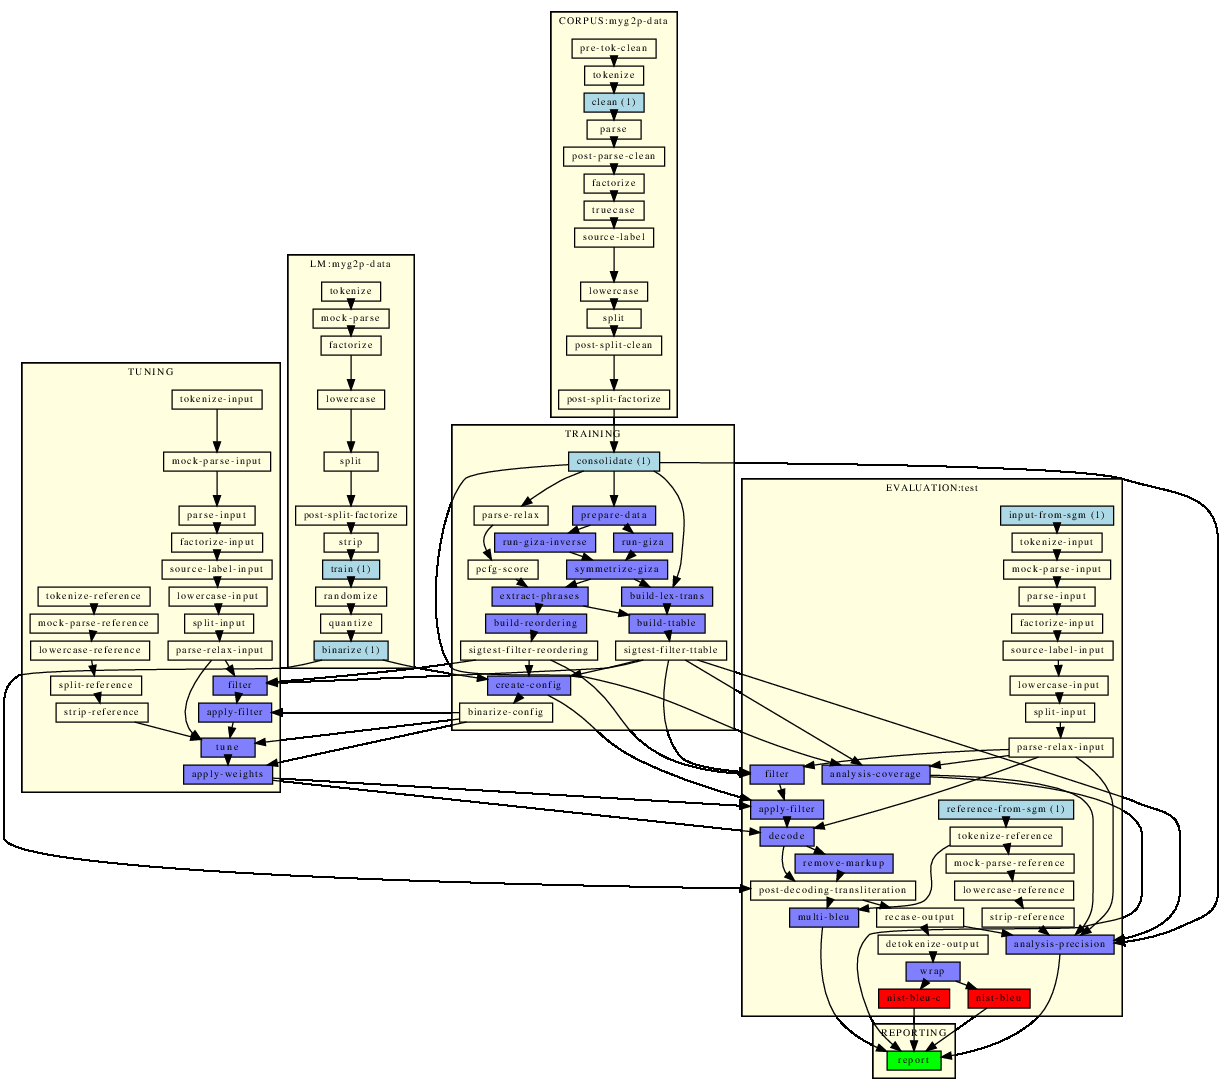

In [4]:
Image(filename=f'{BASELINE_DIR}/ph-my/steps/2/graph.2.png', width=800)

In [5]:
# find error files
!find {BASELINE_DIR} -path '*/steps/2/*.STDERR'

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/EVALUATION_test_analysis-precision.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/TRAINING_prepare-data.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/TRAINING_symmetrize-giza.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/TRAINING_build-lex-trans.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/TUNING_apply-weights.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/EVALUATION_test_wrap.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/EVALUATION_test_filter.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/2/EVALUATION_test_nist-bleu.2.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translati

In [6]:
# check errors
!cat {BASELINE_DIR}/my-ph/steps/2/EVALUATION_test_nist-bleu.2.STDERR
!echo
!cat {BASELINE_DIR}/my-ph/steps/2/EVALUATION_test_nist-bleu-c.2.STDERR
!echo
!cat {BASELINE_DIR}/ph-my/steps/2/EVALUATION_test_nist-bleu-c.2.STDERR
!echo
!cat {BASELINE_DIR}/ph-my/steps/2/EVALUATION_test_nist-bleu.2.STDERR

Can't find Unicode property definition "Line_Break" in regex; marked by <-- HERE in m/\p{Line_Break} <-- HERE \p{Zl}/ at /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl line 950.

Can't find Unicode property definition "Line_Break" in regex; marked by <-- HERE in m/\p{Line_Break} <-- HERE \p{Zl}/ at /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl line 950.

Can't find Unicode property definition "Line_Break" in regex; marked by <-- HERE in m/\p{Line_Break} <-- HERE \p{Zl}/ at /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl line 950.

Can't find Unicode property definition "Line_Break" in regex; marked by <-- HERE in m/\p{Line_Break} <-- HERE \p{Zl}/ at /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl line 950.


## Run 2: Fix
### Enable NIST-BLEU Scores via Perl

In [7]:
# check perl version
!perl -e 'print $^V, " @", $^X, "\n"'

!echo

# test for line break
!perl -e 'print $^V, " @", $^X, "\n"; "x" =~ /\p{Line_Break}/; print "Line_Break OK\n"'

v5.38.2 @/usr/bin/perl

Can't find Unicode property definition "Line_Break" in regex; marked by <-- HERE in m/\p{Line_Break} <-- HERE / at -e line 1.


After trying different Perl versions, googling, and tinkering around, I found that the error is caused by `Line_Break` requiring a value such as:
```perl
\p{Line_Break=Hyphen}
```

instead of 
```perl
\p{Line_Break}
```

Source: https://groups.google.com/g/perl.perl5.porters/c/KxlzrUiGqsU/m/MWEp-EVqKEEJ

In [8]:
!perl -e 'print $^V, " @", $^X, "\n"; "x" =~ /\p{Line_Break=Hyphen}/; print "Line_Break OK\n"'

v5.38.2 @/usr/bin/perl
Line_Break OK


In the Moses SMT Framework, a script called at `ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl` on line 950 uses:
```perl
$norm_text =~ s/\p{Line_Break}\p{Zl}//g;
```

The issue can be fixed by changing the line to:
```perl
$norm_text =~ s/\p{Line_Break=Hyphen}\p{Zl}//g;
```

## Run 3: Machine Translation

In [9]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/config.baseline.ph-my

real	0m41.353s
user	0m4.476s
sys	0m0.557s


## Run 3: Results

In [10]:
# find error files
!find {BASELINE_DIR} -path '*/steps/3/*.STDERR'

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/3/REPORTING_report.3.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/3/EVALUATION_test_nist-bleu.3.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/3/EVALUATION_test_nist-bleu-c.3.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps/3/REPORTING_report.3.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps/3/EVALUATION_test_nist-bleu.3.STDERR
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps/3/EVALUATION_test_nist-bleu-c.3.STDERR


In [11]:
# check errors
!cat /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/3/REPORTING_report.3.STDERR
!cat /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/3/EVALUATION_test_nist-bleu.3.STDERR
!cat /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/steps/3/EVALUATION_test_nist-bleu-c.3.STDERR
!cat /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps/3/REPORTING_report.3.STDERR
!cat /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps/3/EVALUATION_test_nist-bleu.3.STDERR
!cat /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps/3/EVALUATION_test_nist-bleu-c.3.STDERR

Surprisingly, there is no error in run 3.

In [12]:
# read log
!tail -30 {BASELINE_DIR}/logs/run1.log

46 TRAINING:build-reordering ->	re-using (2)
45 TRAINING:build-ttable ->	re-using (2)
42 TRAINING:create-config ->	re-using (2)
27 TUNING:filter ->	re-using (2)
26 TUNING:apply-filter ->	re-using (2)
25 TUNING:tune ->	re-using (2)
24 TUNING:apply-weights ->	re-using (2)
18 EVALUATION:test:filter ->	re-using (2)
17 EVALUATION:test:apply-filter ->	re-using (2)
16 EVALUATION:test:decode ->	re-using (2)
15 EVALUATION:test:remove-markup ->	re-using (2)
11 EVALUATION:test:wrap ->	re-using (2)
10 EVALUATION:test:reference-from-sgm ->	re-using (1)
5 EVALUATION:test:nist-bleu ->	run
4 EVALUATION:test:nist-bleu-c ->	run
3 EVALUATION:test:multi-bleu ->	re-using (2)
2 EVALUATION:test:analysis-coverage ->	re-using (2)
1 EVALUATION:test:analysis-precision ->	re-using (2)
0 REPORTING:report ->	run

EXECUTE STEPS
number of steps doable or running: 2 at Thu May 21 11:52:23 AM +07 2026
	doable: EVALUATION:test:nist-bleu-c
	doable: EVALUATION:test:nist-bleu
	executing /home/lawun330/Desktop/basic-statist

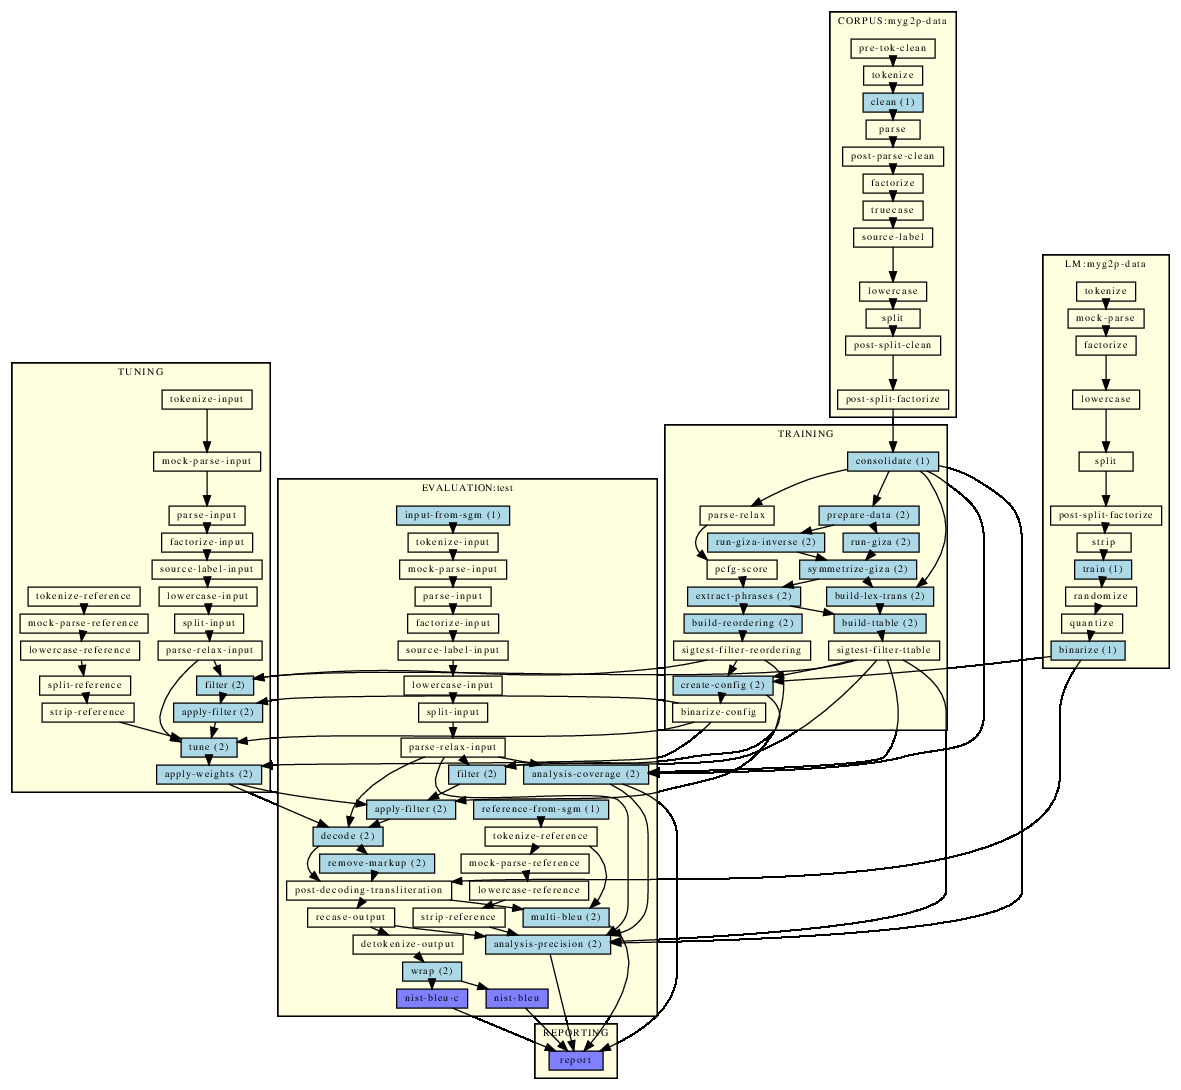

In [13]:
# check graphs
Image(filename=f'{BASELINE_DIR}/my-ph/steps/3/graph.3.png', width=800)

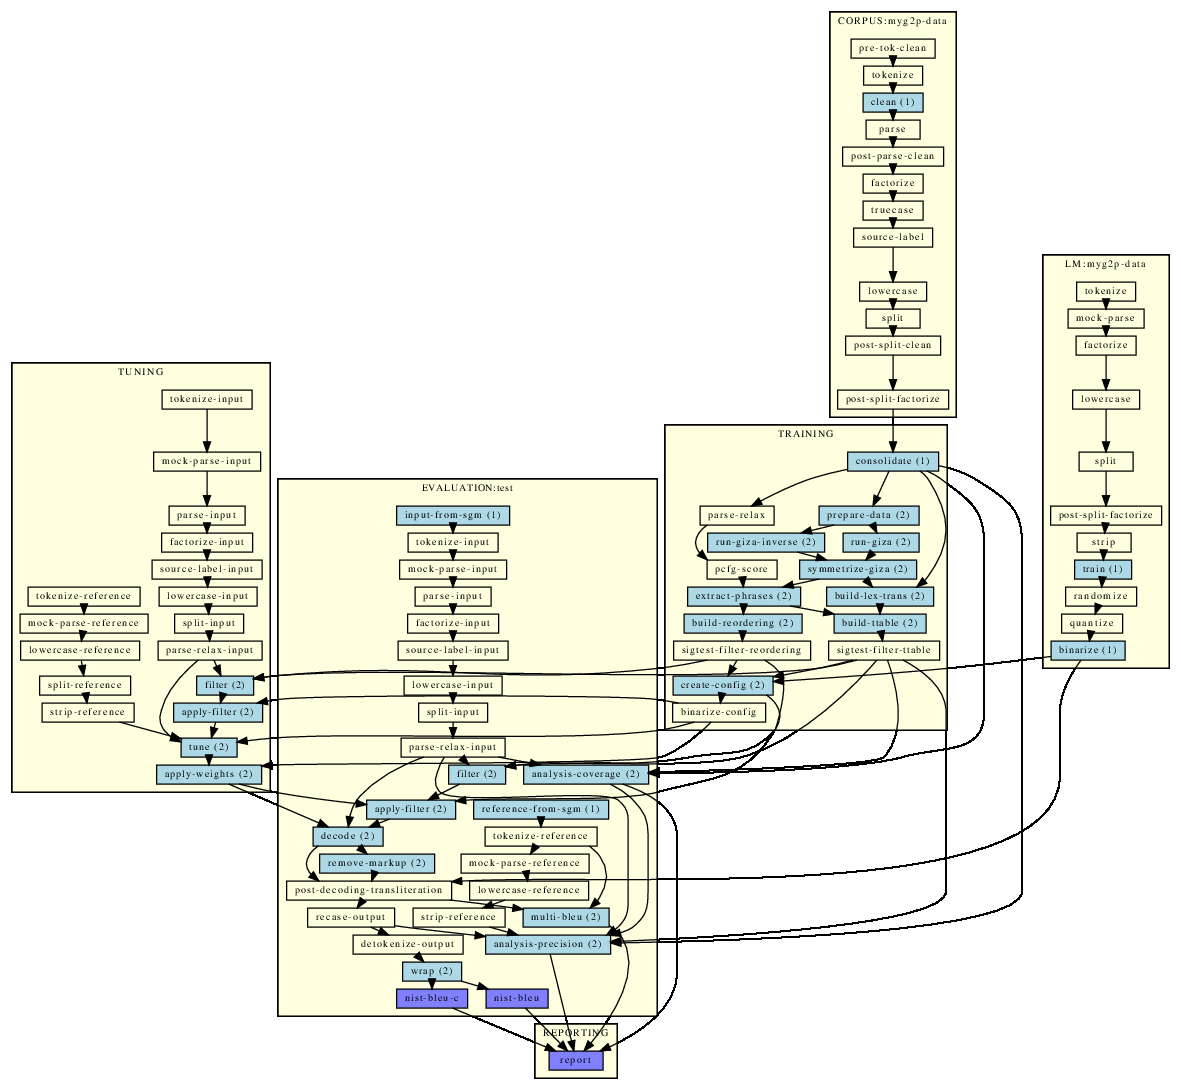

In [14]:
# check graphs
Image(filename=f'{BASELINE_DIR}/ph-my/steps/3/graph.3.png', width=800)

## Run 3: All BLEU Scores

Run 3 is built on top of run 2 and therefore has the same `multi-bleu.2`. However, the `nist-bleu` and `nist-bleu-c` scores for run 3 are no longer empty, unlike in run 2.

In [15]:
!find {BASELINE_DIR}/my-ph/evaluation -type f -name "*bleu*"
!find {BASELINE_DIR}/ph-my/evaluation -type f -name "*bleu*"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu-c.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu-c.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.analysis.2/bleu-annotation
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.nist-bleu-c.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.nist-bleu.3
/home/lawun330/Desktop/basic-statistical-

In [16]:
%cd {BASELINE_DIR}/my-ph/evaluation

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation


In [17]:
!echo '---- my-ph run 2 nist-bleu starts ----'
!cat test.nist-bleu.2
!echo '---- my-ph run 2 nist-bleu ends ----'

!echo

!echo '---- my-ph run 3 nist-bleu starts ----'
!cat test.nist-bleu.3
!echo '---- my-ph run 3 nist-bleu ends ----'

---- my-ph run 2 nist-bleu starts ----
---- my-ph run 2 nist-bleu ends ----

---- my-ph run 3 nist-bleu starts ----
MT evaluation scorer began on 2026 May 21 at 11:52:08
command line:  /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl -s /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.my.src.sgm -r /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.ph.ref.sgm -t /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.detokenized.sgm.2
  Evaluation of any-to-ph translation using:
    src set "Burmese_G2P_data" (1 docs, 2802 segs)
    ref set "Burmese_G2P_data" (1 refs)
    tst set "Burmese_G2P_data" (1 systems)

length ratio: 1.00163132137031 (11052/11034), penalty (log): 0
NIST score = 10.5825  BLEU score = 0.7557 for system "Edinburgh"

# ------------------------------------------------------------------------

Individual N-gram scoring
        1-gram   2

In [18]:
!echo '---- my-ph run 2 nist-bleu-c starts ----'
!cat test.nist-bleu-c.2
!echo '---- my-ph run 2 nist-bleu-c ends ----'

!echo

!echo '---- my-ph run 3 nist-bleu-c starts ----'
!cat test.nist-bleu-c.3
!echo '---- my-ph run 3 nist-bleu-c ends ----'

---- my-ph run 2 nist-bleu-c starts ----
---- my-ph run 2 nist-bleu-c ends ----

---- my-ph run 3 nist-bleu-c starts ----
MT evaluation scorer began on 2026 May 21 at 11:52:13
command line:  /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl -c -c -s /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.my.src.sgm -r /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.ph.ref.sgm -t /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.detokenized.sgm.2
  Evaluation of any-to-ph translation using:
    src set "Burmese_G2P_data" (1 docs, 2802 segs)
    ref set "Burmese_G2P_data" (1 refs)
    tst set "Burmese_G2P_data" (1 systems)

length ratio: 1.00163132137031 (11052/11034), penalty (log): 0
NIST score = 10.5825  BLEU score = 0.7557 for system "Edinburgh"

# ------------------------------------------------------------------------

Individual N-gram scoring
      

In [19]:
%cd {BASELINE_DIR}/ph-my/evaluation

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation


In [20]:
!echo '---- ph-my run 2 nist-bleu starts ----'
!cat test.nist-bleu.2
!echo '---- ph-my run 2 nist-bleu ends ----'

!echo

!echo '---- ph-my run 3 nist-bleu starts ----'
!cat test.nist-bleu.3
!echo '---- ph-my run 3 nist-bleu ends ----'

---- ph-my run 2 nist-bleu starts ----
---- ph-my run 2 nist-bleu ends ----

---- ph-my run 3 nist-bleu starts ----
MT evaluation scorer began on 2026 May 21 at 11:52:33
command line:  /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl -s /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.ph.src.sgm -r /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.my.ref.sgm -t /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.detokenized.sgm.2
  Evaluation of any-to-my translation using:
    src set "Burmese_G2P_data" (1 docs, 2802 segs)
    ref set "Burmese_G2P_data" (1 refs)
    tst set "Burmese_G2P_data" (1 systems)

length ratio: 1.0019870839543 (8068/8052), penalty (log): 0
NIST score = 11.3539  BLEU score = 0.7775 for system "Edinburgh"

# ------------------------------------------------------------------------

Individual N-gram scoring
        1-gram   2-gr

In [21]:
!echo '---- ph-my run 2 nist-bleu-c starts ----'
!cat test.nist-bleu-c.2
!echo '---- ph-my run 2 nist-bleu-c ends ----'

!echo

!echo '---- ph-my run 3 nist-bleu-c starts ----'
!cat test.nist-bleu-c.3
!echo '---- ph-my run 3 nist-bleu-c ends ----'

---- ph-my run 2 nist-bleu-c starts ----
---- ph-my run 2 nist-bleu-c ends ----

---- ph-my run 3 nist-bleu-c starts ----
MT evaluation scorer began on 2026 May 21 at 11:52:28
command line:  /home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic/mteval-v13a.pl -c -c -s /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.ph.src.sgm -r /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm/test.my.ref.sgm -t /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.detokenized.sgm.2
  Evaluation of any-to-my translation using:
    src set "Burmese_G2P_data" (1 docs, 2802 segs)
    ref set "Burmese_G2P_data" (1 refs)
    tst set "Burmese_G2P_data" (1 systems)

length ratio: 1.0019870839543 (8068/8052), penalty (log): 0
NIST score = 11.3539  BLEU score = 0.7775 for system "Edinburgh"

# ------------------------------------------------------------------------

Individual N-gram scoring
        1

In [22]:
%cd {BASELINE_DIR}/my-ph/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation
BLEU = 69.14, 85.2/72.4/64.3/57.6 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [23]:
%cd {BASELINE_DIR}/ph-my/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation
BLEU = 78.15, 87.8/79.4/75.0/71.3 (BP=1.000, ratio=1.000, hyp_len=8047, ref_len=8048)


## Run 3: Alignment Tables

### PH-MY Under MY-PH

In [24]:
!ls {BASELINE_DIR}/my-ph/training -F --color=auto

corpus.1.my@  corpus.1.ph@  giza.2/  giza-inverse.2/  prepared.1/  prepared.2/


In [25]:
!ls {BASELINE_DIR}/my-ph/training/giza.2 -F --color=auto

ph-my.A3.final.gz  ph-my.cooc  ph-my.gizacfg


In [26]:
%cd {BASELINE_DIR}/my-ph/training/giza.2
!mkdir extracted/
!ls {BASELINE_DIR}/my-ph/training/giza.2 -F --color=auto

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/training/giza.2
extracted/  ph-my.A3.final.gz  ph-my.cooc  ph-my.gizacfg


In [27]:
!cp {BASELINE_DIR}/my-ph/training/giza.2/ph-my.A3.final.gz {BASELINE_DIR}/my-ph/training/giza.2/extracted/
%cd {BASELINE_DIR}/my-ph/training/giza.2/extracted
!gunzip {BASELINE_DIR}/my-ph/training/giza.2/extracted/ph-my.A3.final.gz

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/training/giza.2/extracted


In [28]:
!head -n 50 ./ph-my.A3.final

# Sentence pair (1) source length 3 target length 3 alignment score : 0.00894821
pja' tha' hsaun 
NULL ({ }) ပြာ ({ 1 }) သာဒ် ({ 2 }) ဆောင် ({ 3 }) 
# Sentence pair (2) source length 5 target length 5 alignment score : 0.00844814
kou bain sa kyi. dai' 
NULL ({ }) ကိုယ် ({ 1 }) ပိုင် ({ 2 }) စာ ({ 3 }) ကြည့် ({ 4 }) တိုက် ({ 5 }) 
# Sentence pair (3) source length 3 target length 3 alignment score : 0.0957379
thein: do: hsa: 
NULL ({ }) သိန် ({ 1 }) ဓော ({ 2 }) ဆား ({ 3 }) 
# Sentence pair (4) source length 3 target length 3 alignment score : 0.0503302
sa: thau' hsain 
NULL ({ }) စား ({ 1 }) သောက် ({ 2 }) ဆိုင် ({ 3 }) 
# Sentence pair (5) source length 2 target length 2 alignment score : 0.131196
kyou: zin 
NULL ({ }) ကြိုး ({ 1 }) စင် ({ 2 }) 
# Sentence pair (6) source length 2 target length 2 alignment score : 0.176591
hsaun kyin: 
NULL ({ }) ဆောင် ({ 1 }) ကြဉ်း ({ 2 }) 
# Sentence pair (7) source length 5 target length 5 alignment score : 0.0116199
lo: ba. the' ka ja. 
NULL ({ }) လ

### MY-PH Under PH-MY

In [29]:
!ls {BASELINE_DIR}/ph-my/training -F --color=auto

corpus.1.my@  corpus.1.ph@  giza.2/  giza-inverse.2/  prepared.1/  prepared.2/


In [30]:
!ls {BASELINE_DIR}/ph-my/training/giza.2 -F --color=auto

my-ph.A3.final.gz  my-ph.cooc  my-ph.gizacfg


In [31]:
%cd {BASELINE_DIR}/ph-my/training/giza.2
!mkdir extracted/
!ls {BASELINE_DIR}/ph-my/training/giza.2 -F --color=auto

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/training/giza.2
extracted/  my-ph.A3.final.gz  my-ph.cooc  my-ph.gizacfg


In [32]:
!cp {BASELINE_DIR}/ph-my/training/giza.2/my-ph.A3.final.gz {BASELINE_DIR}/ph-my/training/giza.2/extracted/
%cd {BASELINE_DIR}/ph-my/training/giza.2/extracted
!gunzip {BASELINE_DIR}/ph-my/training/giza.2/extracted/my-ph.A3.final.gz

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/training/giza.2/extracted


In [33]:
!head -n 50 ./my-ph.A3.final

# Sentence pair (1) source length 3 target length 3 alignment score : 0.000397751
ပြာ သာဒ် ဆောင် 
NULL ({ }) pja' ({ 1 }) tha' ({ 2 }) hsaun ({ 3 }) 
# Sentence pair (2) source length 5 target length 5 alignment score : 0.0478499
ကိုယ် ပိုင် စာ ကြည့် တိုက် 
NULL ({ }) kou ({ 1 }) bain ({ 2 }) sa ({ 3 }) kyi. ({ 4 }) dai' ({ 5 }) 
# Sentence pair (3) source length 3 target length 3 alignment score : 0.00134887
သိန် ဓော ဆား 
NULL ({ }) thein: ({ 1 }) do: ({ 2 }) hsa: ({ 3 }) 
# Sentence pair (4) source length 3 target length 3 alignment score : 0.250547
စား သောက် ဆိုင် 
NULL ({ }) sa: ({ 1 }) thau' ({ 2 }) hsain ({ 3 }) 
# Sentence pair (5) source length 2 target length 2 alignment score : 0.126273
ကြိုး စင် 
NULL ({ }) kyou: ({ 1 }) zin ({ 2 }) 
# Sentence pair (6) source length 2 target length 2 alignment score : 0.0157622
ဆောင် ကြဉ်း 
NULL ({ }) hsaun ({ 1 }) kyin: ({ 2 }) 
# Sentence pair (7) source length 5 target length 5 alignment score : 0.0183169
လော ဘ သက် ကာ ယ 
NULL ({ }) lo: (

## Run 3: Tables

### Phrase Table

In [34]:
!ls {BASELINE_DIR}/my-ph/model -F --color=auto

aligned.2.grow-diag-final-and  lex.2.f2e
extract.2.inv.sorted.gz        moses.ini.2
extract.2.o.sorted.gz          phrase-table.2.gz
extract.2.sorted.gz            reordering-table.2.wbe-msd-bidirectional-fe.gz
lex.2.e2f


In [35]:
%cd {BASELINE_DIR}/my-ph/model
!mkdir extracted/
!ls {BASELINE_DIR}/my-ph/model -F --color=auto

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model
aligned.2.grow-diag-final-and  lex.2.e2f
extract.2.inv.sorted.gz        lex.2.f2e
extract.2.o.sorted.gz          moses.ini.2
extract.2.sorted.gz            phrase-table.2.gz
extracted/                     reordering-table.2.wbe-msd-bidirectional-fe.gz


In [36]:
!cp phrase-table.2.gz ./extracted/
%cd ./extracted
!gunzip phrase-table.2.gz

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model/extracted


In [37]:
!head -n 30 ./phrase-table.2

... ||| ... ||| 0.75 0.75 1 1 ||| 0-0 ||| 8 6 6 ||| |||
... ငြား ||| ... nja: ||| 0.188551 0.15 0.188551 1 ||| 0-0 1-1 ||| 1 1 1 ||| |||
... စဉ် ||| ... zin ||| 0.188551 0.327586 0.188551 0.59375 ||| 0-0 1-1 ||| 1 1 1 ||| |||
... ဖြစ် ||| ... hpji' ||| 0.472371 0.742105 0.472371 0.912621 ||| 0-0 1-1 ||| 2 2 2 ||| |||
... ဖြစ် စေ ... ||| ... hpji' sei ... ||| 0.188551 0.556579 0.188551 0.456311 ||| 0-0 1-1 2-2 3-3 ||| 1 1 1 ||| |||
... ဖြစ် စေ ... ဖြစ် ||| ... hpji' sei ... hpji' ||| 0.188551 0.55072 0.188551 0.416439 ||| 0-0 1-1 2-2 3-3 4-4 ||| 1 1 1 ||| |||
... ဖြစ် စေ ||| ... hpji' sei ||| 0.472371 0.742105 0.472371 0.456311 ||| 0-0 1-1 2-2 ||| 2 2 2 ||| |||
... ရိုး ... ||| ... jou: ... ||| 0.188551 0.50431 0.188551 0.981132 ||| 0-0 1-1 2-2 ||| 1 1 1 ||| |||
... ရိုး ... စဉ် ||| ... jou: ... zin ||| 0.188551 0.220273 0.188551 0.582547 ||| 0-0 1-1 2-2 3-3 ||| 1 1 1 ||| |||
... ရိုး ||| ... jou: ||| 0.188551 0.672414 0.188551 0.981132 ||| 0-0 1-1 ||| 1 1 1 ||| |||
... လို ... ||| ... 

### Reordering Table

In [38]:
%cd {BASELINE_DIR}/my-ph/model
!cp reordering-table.2.wbe-msd-bidirectional-fe.gz ./extracted/
%cd ./extracted
!gunzip reordering-table.2.wbe-msd-bidirectional-fe.gz

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model/extracted


In [39]:
!head -n 30 ./reordering-table.2.wbe-msd-bidirectional-fe

... ||| ... ||| 0.866667 0.0666667 0.0666667 0.866667 0.0666667 0.0666667
... ငြား ||| ... nja: ||| 0.6 0.2 0.2 0.6 0.2 0.2
... စဉ် ||| ... zin ||| 0.6 0.2 0.2 0.6 0.2 0.2
... ဖြစ် ||| ... hpji' ||| 0.714286 0.142857 0.142857 0.714286 0.142857 0.142857
... ဖြစ် စေ ... ||| ... hpji' sei ... ||| 0.6 0.2 0.2 0.6 0.2 0.2
... ဖြစ် စေ ... ဖြစ် ||| ... hpji' sei ... hpji' ||| 0.6 0.2 0.2 0.6 0.2 0.2
... ဖြစ် စေ ||| ... hpji' sei ||| 0.714286 0.142857 0.142857 0.714286 0.142857 0.142857
... ရိုး ... ||| ... jou: ... ||| 0.6 0.2 0.2 0.6 0.2 0.2
... ရိုး ... စဉ် ||| ... jou: ... zin ||| 0.6 0.2 0.2 0.6 0.2 0.2
... ရိုး ||| ... jou: ||| 0.6 0.2 0.2 0.6 0.2 0.2
... လို ... ||| ... lou ... ||| 0.6 0.2 0.2 0.6 0.2 0.2
... လို ... ငြား ||| ... lou ... nja: ||| 0.6 0.2 0.2 0.6 0.2 0.2
... လို ||| ... lou ||| 0.6 0.2 0.2 0.6 0.2 0.2
က ||| ga ||| 0.777778 0.111111 0.111111 0.777778 0.111111 0.111111
က ||| ga- ||| 0.995181 0.00240964 0.00240964 0.995181 0.00240964 0.00240964
က ||| ga. ||| 0.957447 0.0212

In [40]:
!ls

phrase-table.2	reordering-table.2.wbe-msd-bidirectional-fe


## Run 3: Configuration Files

### moses.ini (Training)

In [41]:
!ls {BASELINE_DIR}/my-ph/ -F --color=auto

config.baseline.my-ph  evaluation/  model/  training/
corpus/                lm/          steps/  tuning/


In [42]:
!ls {BASELINE_DIR}/my-ph/model

aligned.2.grow-diag-final-and  lex.2.e2f
extract.2.inv.sorted.gz        lex.2.f2e
extract.2.o.sorted.gz	       moses.ini.2
extract.2.sorted.gz	       phrase-table.2.gz
extracted		       reordering-table.2.wbe-msd-bidirectional-fe.gz


In [43]:
!cat {BASELINE_DIR}/my-ph/model/moses.ini.2

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model/phrase-table.2 input-factor=0 output-factor=0
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model/reordering-table.2.wbe-msd-bidirectional-fe.gz
Distortion
KENLM name=LM0 factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/lm/myg2p-data.binlm.1 order=5

# dense weights for feature functions
[weight]
# The default weights are NOT optimized for translation quality. You MUST tune the weights.
# Documentation fo

### moses.ini (Filtering)

In [44]:
!ls {BASELINE_DIR}/my-ph/tuning

filtered.2  moses.filtered.ini.2  moses.ini.2  moses.tuned.ini.2  tmp.2


In [45]:
!cat {BASELINE_DIR}/my-ph/tuning/moses.filtered.ini.2

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/tuning/filtered.2/phrase-table.0-0.1.1.gz input-factor=0 output-factor=0 
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/tuning/filtered.2/reordering-table.2.wbe-msd-bidirectional-fe.0-0.1 
Distortion
KENLM name=LM0 factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/lm/myg2p-data.binlm.1 order=5

# dense weights for feature functions
[weight]
# The default weights are NOT optimized for translation quality. You MUS

### moses.ini (Tuning)

In [46]:
!ls {BASELINE_DIR}/my-ph/tuning

filtered.2  moses.filtered.ini.2  moses.ini.2  moses.tuned.ini.2  tmp.2


In [47]:
!cat {BASELINE_DIR}/my-ph/tuning/moses.tuned.ini.2

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model/phrase-table.2 input-factor=0 output-factor=0
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/model/reordering-table.2.wbe-msd-bidirectional-fe.gz
Distortion
KENLM name=LM0 factor=0 path=/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/lm/myg2p-data.binlm.1 order=5

# core weights
[weight]
LexicalReordering0= 0.0922185 0.055738 0.0262305 0.0192642 0.0270823 0.0805866
Distortion0= 0.0939339
LM0= 0.0718413
WordPenalty0= 0.